Задание 4. Вариант 3
Выполнил: Радченко Анатолий Группа: МГК-53

Размер: (178, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    

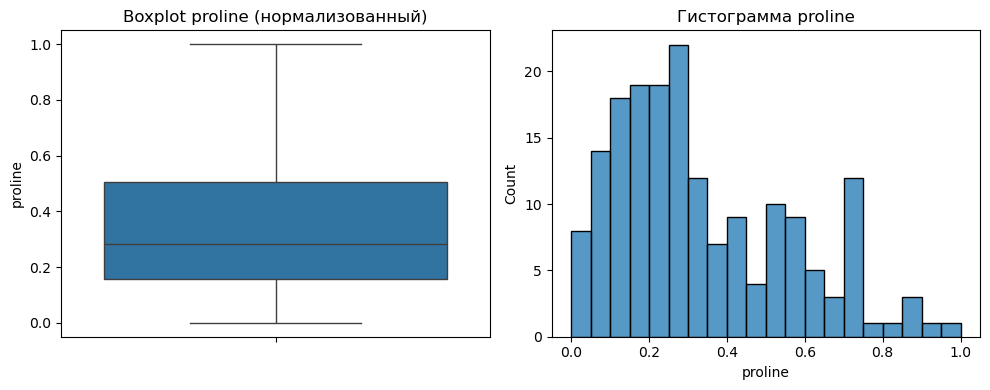

Границы: нижняя=-0.3597, верхняя=1.0226
Количество выбросов в proline: 0
Размер после удаления выбросов: (178, 15) (было (178, 15))
Датасет сохранён как 'cleaned_wine.csv'


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import MinMaxScaler

np.random.seed(42)

wine_data = load_wine()
df = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
df['target'] = wine_data.target

print("Размер:", df.shape)
df.head()


df.info()
print("\nПропуски (изначально):\n", df.isnull().sum())
print("\nДубликаты:", df.duplicated().sum())


df['target'] = df['target'].astype('category')
print(df.dtypes)


n_missing = int(len(df) * 0.1)
missing_idx = np.random.choice(df.index, size=n_missing, replace=False)
df.loc[missing_idx, 'alcohol'] = np.nan
print(f"Пропусков в alcohol после добавления: {df['alcohol'].isnull().sum()}")


alcohol_median_by_class = df.groupby('target', observed=True)['alcohol'].median()
print("Медиана alcohol по классам:\n", alcohol_median_by_class)

df['alcohol'] = df.groupby('target', observed=True)['alcohol'].transform(
    lambda x: x.fillna(x.median())
)
print("Пропусков после заполнения:", df['alcohol'].isnull().sum())


initial_rows = len(df)
df.drop_duplicates(inplace=True)
print(f"Удалено дубликатов: {initial_rows - len(df)}")


df['total_phenols_flav'] = df['total_phenols'] + df['flavanoids']
df[['total_phenols', 'flavanoids', 'total_phenols_flav']].head()


features = df.columns.drop('target')
scaler = MinMaxScaler()
df[features] = scaler.fit_transform(df[features])
df.head()


print("Пропуски после всех операций:\n", df.isnull().sum())

for col in features:
    print(f"{col:30} min={df[col].min():.4f}, max={df[col].max():.4f}")


plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.boxplot(y=df['proline'])
plt.title('Boxplot proline (нормализованный)')
plt.subplot(1,2,2)
sns.histplot(df['proline'], bins=20)
plt.title('Гистограмма proline')
plt.tight_layout()
plt.show()


Q1 = df['proline'].quantile(0.25)
Q3 = df['proline'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['proline'] < lower) | (df['proline'] > upper)]
print(f"Границы: нижняя={lower:.4f}, верхняя={upper:.4f}")
print(f"Количество выбросов в proline: {len(outliers)}")


df_clean = df[~((df['proline'] < lower) | (df['proline'] > upper))]
print(f"Размер после удаления выбросов: {df_clean.shape} (было {df.shape})")


df_clean.to_csv('cleaned_wine.csv', index=False)
print("Датасет сохранён как 'cleaned_wine.csv'")